<a href="https://colab.research.google.com/github/antonellagambarte/deep-learning--CEIA/blob/main/Copia_de_GAMBARTE_ANTONELLA_NEREA_DL_TP1_Co21_prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Resolución trabajo práctico N°1 - Aprendizaje Profundo**

# **PREGUNTA 1**

1 a) Implementación del Gradiente Descendente

Bibliotecas necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Generación de dataset sintético y funciones auxiliares

In [ ]:
np.random.seed(7)

#Generación de dataset sintético
inicio, fin, n = -3, 3, 200
x = np.linspace(inicio, fin, n)

# función no lineal + ruido
y = np.sin(2 * x) + 0.3 * np.random.randn(n)

def forward_pass(w,b,x):
  z= w * x + b # red de una sola neurona
  return np.tanh(z), z # paso resultado por función de activación

# Función de costo
def mse_loss(y_pred,y):
  return np.mean((y_pred - y)**2)

# Función para calcular los gradientes
# recibe el peso, bias, batch de entrada y salida
def gradientes(w, b, x_batch, y_batch):
    m = x_batch.shape[0] # número de filas
    y_hat, z = forward_pass(w, b, x_batch) # propagación hacia adelante
    err = y_hat - y_batch
    dz_dw = (1 - np.tanh(z) ** 2) * x_batch
    dz_db = (1 - np.tanh(z) ** 2)
    dw = (2.0 / m) * np.sum(err * dz_dw) #regla de la cadena
    db = (2.0 / m) * np.sum(err * dz_db) #regla de la cadena
    return dw, db



A continuación, se implementa el algoritmo de Gradiente Descendente

In [ ]:
# La función recibe el valor inicial de w, b, los datos de entrada x, los valores reales y, y la taza de aprendizaje
def gradiente_descendente(w0, b0, x, y, lr):
  epochs = 100 # cantidad de épocas según enunciado
  w, b = w0, b0
  history = {'w': [], 'b': [], 'loss': []}

  for epoch in range(epochs):
      dw, db = gradientes(w, b, x, y)
      w = w - lr * dw
      b = b - lr * db
      y_hat, _ = forward_pass(w, b, x)
      loss = mse_loss(y_hat, y)
      history['w'].append(w)
      history['b'].append(b)
      history['loss'].append(loss)
  return history


Uso del algoritmo para distintos learning rates

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
results = {}

# Inicialización ramdon de w y b para los distintos learning rates
for lr in learning_rates:
    w0 = np.random.randn()
    b0 = np.random.randn()
    results[lr] = {'init': (w0, b0)}

# Ejecutción Gradient Descent para los distintos learning rates
for lr in learning_rates:
    w0, b0 = results[lr]['init']
    hist_gd = gradiente_descendente(w0, b0, x, y, lr)
    results[lr]['gd'] = hist_gd

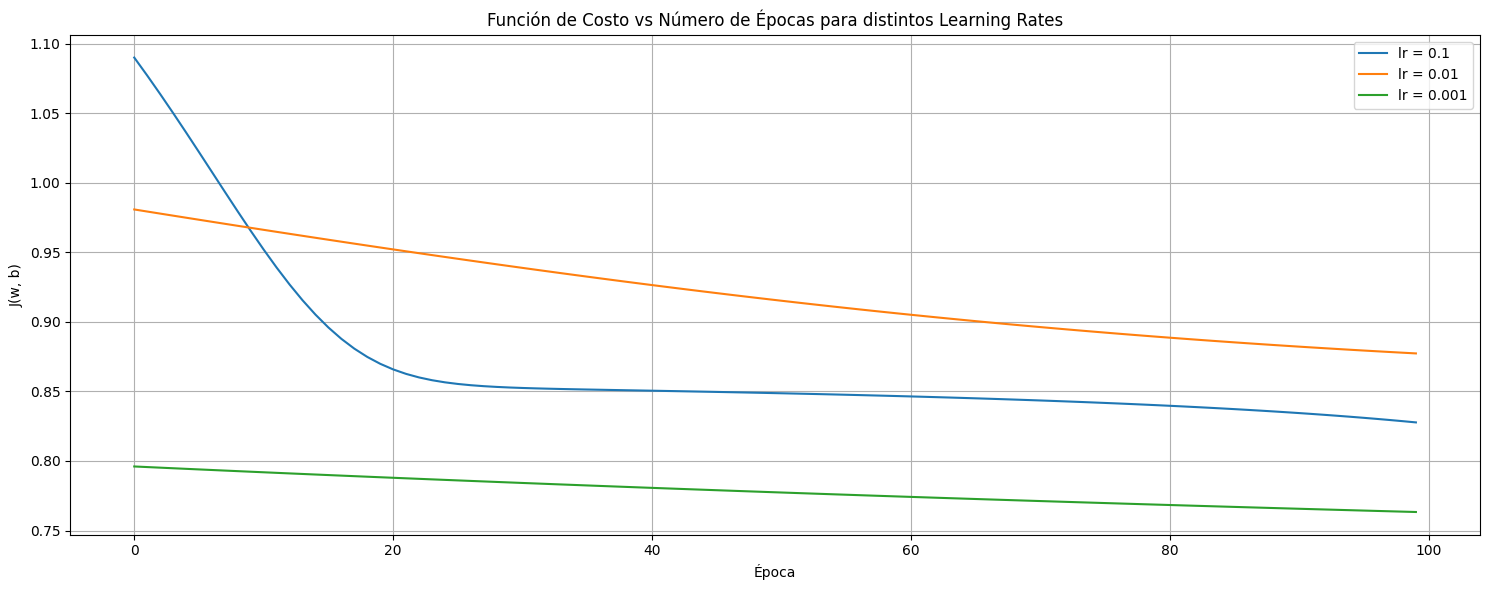

In [ ]:
plt.figure(figsize=(15, 6))

for lr in learning_rates:
    history = results[lr]['gd']
    plt.plot(history['loss'], label=f'lr = {lr}')

plt.xlabel('Época')
plt.ylabel('J(w, b)')
plt.title('Función de Costo vs Número de Épocas para distintos Learning Rates')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

1 b) Implemetación de Adam

In [ ]:
# para beta1, beta2 y eps se toma los valores recomendados en el paper "Adam: A Method for Stochastic Optimization"
# link: https://arxiv.org/pdf/1412.6980
def adam(w0, b0, x, y, lr, epochs=100, batch_size=None, beta1=0.9, beta2=0.999, eps=1e-8):
    np.random.seed(7)
  # inicialización de pesos y bias
    w, b = w0, b0
  # momentos de primer y segundo orden inicializados en cero
    mw, vw = 0.0, 0.0
    mb, vb = 0.0, 0.0
    history = {'w': [], 'b': [], 'loss': []}
    m = x.shape[0]
    step = 0

    # Si batch_size es None -> full-batch
    for t in range(1, epochs + 1):
        if batch_size is None:
            dw, db = gradientes(w, b, x, y)

            step += 1
            # Actualización de momentos
            mw = beta1 * mw + (1 - beta1) * dw
            mb = beta1 * mb + (1 - beta1) * db
            vw = beta2 * vw + (1 - beta2) * (dw ** 2)
            vb = beta2 * vb + (1 - beta2) * (db ** 2)

            # Corrección bias
            mw_hat = mw / (1 - beta1 ** step)
            mb_hat = mb / (1 - beta1 ** step)
            vw_hat = vw / (1 - beta2 ** step)
            vb_hat = vb / (1 - beta2 ** step)

            # Actualización de parámetros
            w = w - lr * mw_hat / (np.sqrt(vw_hat) + eps)
            b = b - lr * mb_hat / (np.sqrt(vb_hat) + eps)
        else:
            # bloque mini-batch
            indices = np.random.permutation(m) # seleccionar un mini-batch aleatorio sin repetición. Esto permite que los gradientes sean estocásticos,
                                                                 # como Adam asume, evitando sesgos por el orden de los datos y mejorando la convergencia.
                                                                 # (https://www.geeksforgeeks.org/machine-learning/difference-between-batch-gradient-descent-and-stochastic-gradient-descent)
            for start in range(0, m, batch_size):
                end = start + batch_size
                x_batch = x[indices[start:end]]
                y_batch = y[indices[start:end]]

                dw, db = gradientes(w, b, x_batch, y_batch)

                step += 1
                # Actualización de momentos
                mw = beta1 * mw + (1 - beta1) * dw
                mb = beta1 * mb + (1 - beta1) * db
                vw = beta2 * vw + (1 - beta2) * (dw ** 2)
                vb = beta2 * vb + (1 - beta2) * (db ** 2)

                # Corrección bias
                mw_hat = mw / (1 - beta1 ** step)
                mb_hat = mb / (1 - beta1 ** step)
                vw_hat = vw / (1 - beta2 ** step)
                vb_hat = vb / (1 - beta2 ** step)

                # Actualización de parámetros
                w = w - lr * mw_hat / (np.sqrt(vw_hat) + eps)
                b = b - lr * mb_hat / (np.sqrt(vb_hat) + eps)


        y_hat, _ = forward_pass(w, b, x)
        loss = mse_loss(y_hat, y)
        history['w'].append(w)
        history['b'].append(b)
        history['loss'].append(loss)

    return history



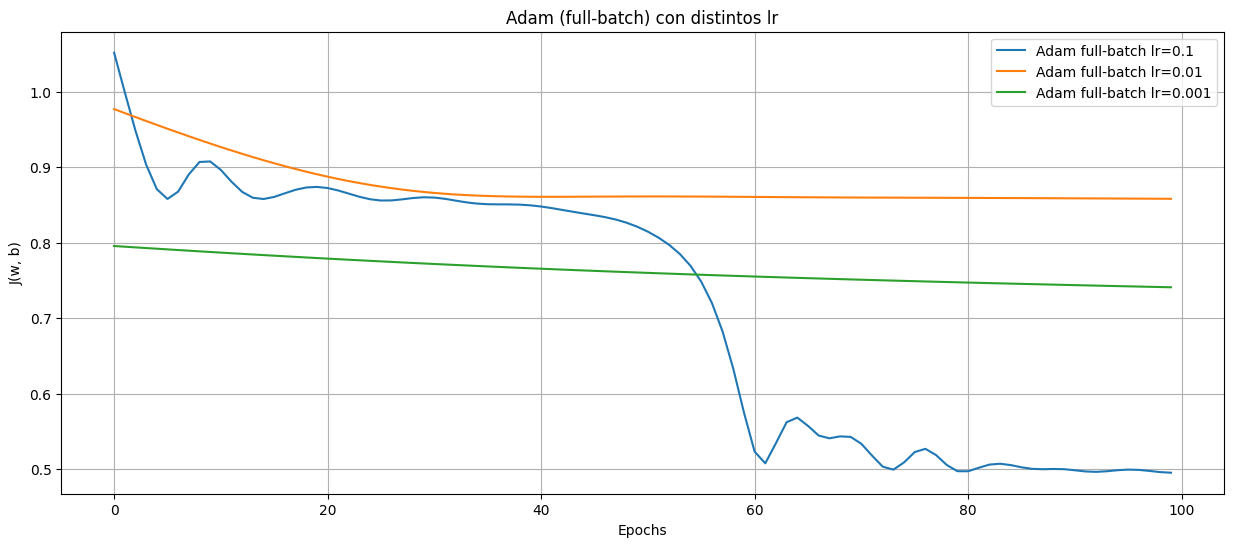

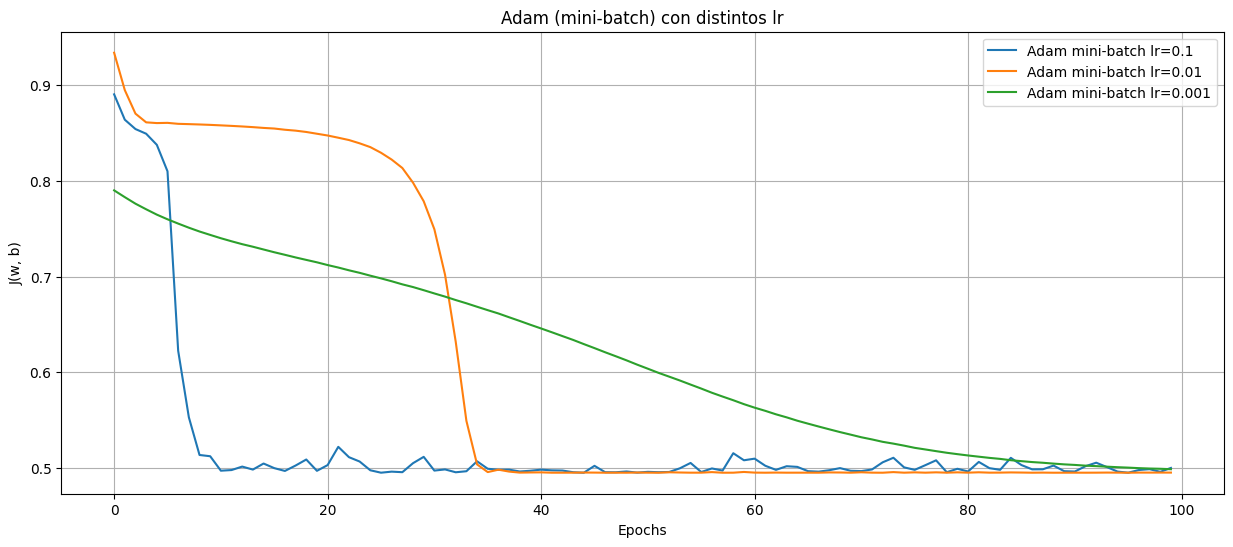

In [ ]:
epochs = 100
# Ejecutar Adam full-batch (usando mismos w0,b0 que GD por lr)
for lr in learning_rates:
    w0, b0 = results[lr]['init']
    hist_adam_full = adam(w0, b0, x, y, lr, epochs=epochs, batch_size=None)
    results[lr]['adam_full'] = hist_adam_full

# Ejecutar Adam mini-batch (batch size elegido = 20)
batch_size = 20
for lr in learning_rates:
    w0, b0 = results[lr]['init']
    hist_adam_mini = adam(w0, b0, x, y, lr, epochs=epochs, batch_size=batch_size)
    results[lr]['adam_mini'] = hist_adam_mini


# Adam full-batch
plt.figure(figsize=(15,6))
for lr in learning_rates:
    history_adam = results[lr]['adam_full']
    plt.plot(history_adam["loss"], label=f"Adam full-batch lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("J(w, b)")
plt.title("Adam (full-batch) con distintos lr")
plt.grid(True)
plt.legend()
plt.show()

# Adam mini-batch
plt.figure(figsize=(15,6))
for lr in learning_rates:
    history_adam_mb = results[lr]['adam_mini']
    plt.plot(history_adam_mb["loss"], label=f"Adam mini-batch lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("J(w, b)")
plt.title("Adam (mini-batch) con distintos lr")
plt.grid(True)
plt.legend()
plt.show()



1c)

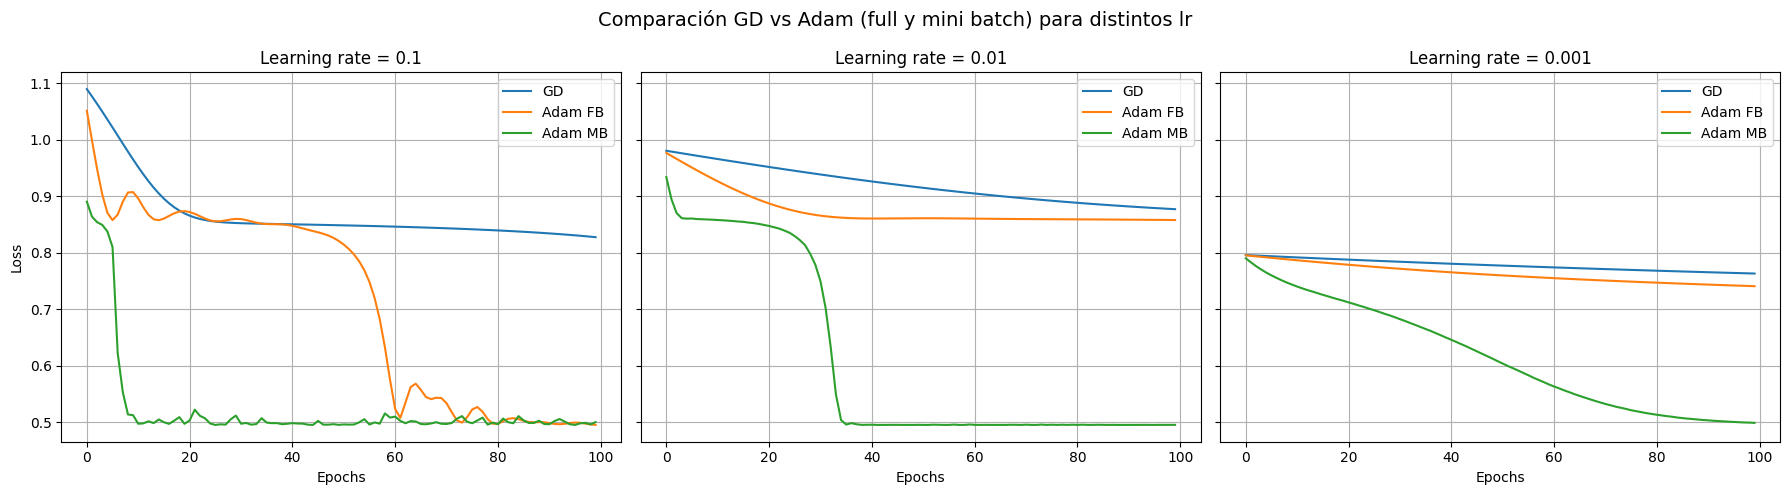

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, lr in enumerate(learning_rates):
    ax = axes[i]
    ax.plot(results[lr]["gd"]["loss"], label="GD")
    ax.plot(results[lr]["adam_full"]["loss"], label="Adam FB")
    ax.plot(results[lr]["adam_mini"]["loss"], label="Adam MB")
    ax.set_title(f"Learning rate = {lr}")
    ax.set_xlabel("Epochs")
    if i == 0:
        ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

plt.suptitle("Comparación GD vs Adam (full y mini batch) para distintos lr", fontsize=14)
plt.tight_layout()
plt.show()

Para learning rate = 0.1
- En el caso de Gradient Descent (GD), el loss baja al principio pero luego se aplana y converge lentamente.

- En el caso de Adam full batch, el loss comienza con oscilaciones pero mas o menos a partir de la época 55 comienza a bajar considerablemente. Si bien comienza con oscilaciones, consigue un loss mejor que GD. En la época 60 comienza a estabilizarse.

- Para el caso de Adam mini batch, es similar al Adam FB, pero logra una disminución mucho más rápida del loss y llega al mínimo más rápidamente. De hecho, es el optimizador que logra el menor valor de loss en este caso, con una convergencia más rápida que ambos métodos anteriores.

Para learning rate = 0.01
- Para GD, el loss disminuye de forma más lenta pero prograsiva pero con peor resultado que con lr = 0.1.
- Para Adam full bach, el loss desciende suavemente pero con peor resultado que lr = 0.1.
- En el caso de Adam mini batch, el comportamiento es más lento y menos eficiente que con lr = 0.1, pero no está completamente estabilizado en las primeras épocas como Adam Full Batch. Sin embargo, en comparación con Adam full batch, tiene una convergencia más rápida, aunque no tan eficiente como con el lr = 0.1. Ademas, en este caso tambien se llega a un mejor valor de loss si comparamos con GD y Adam full batch.

Para learning rate = 0.001
- GD: se obtienen mejores resultado que con los anteriores lr, pero no mejor que adam. El loss sigue siendo alto.
- Adam full batch: la disminución del loss es más lenta y estable, pero no logra alcanzar los mejores resultados en comparación con el lr = 0.1. El resultado es levemente mejor que GD.
- Adam mini batch: a pesar de ser lento, el optimizador sigue mostrando una convergencia más estable y eficiente que Adam full batch, alcanzando valores de pérdida más bajos a lo largo de las épocas, aunque sigue siendo más lento que con lr = 0.1.

### **Conclusiones**
- GD: depende mucho del lr, converge más lento y no alcanza mínimos de loss para ninguno de los lr.
- Adam full-batch: mejora frente a GD, pero con lr=0.1 recién muestra buenos resultados después de muchas épocas.
- Adam mini-batch: es el más eficiente de los tres. Con lr=0.1 llega al mejor costo rápido. Con lr más bajos es más lento, pero para los tres casos funciona mejor comparado con GD y Adam full batch.

1d) Visualización en 3D de la trayectoria de aprendizaje

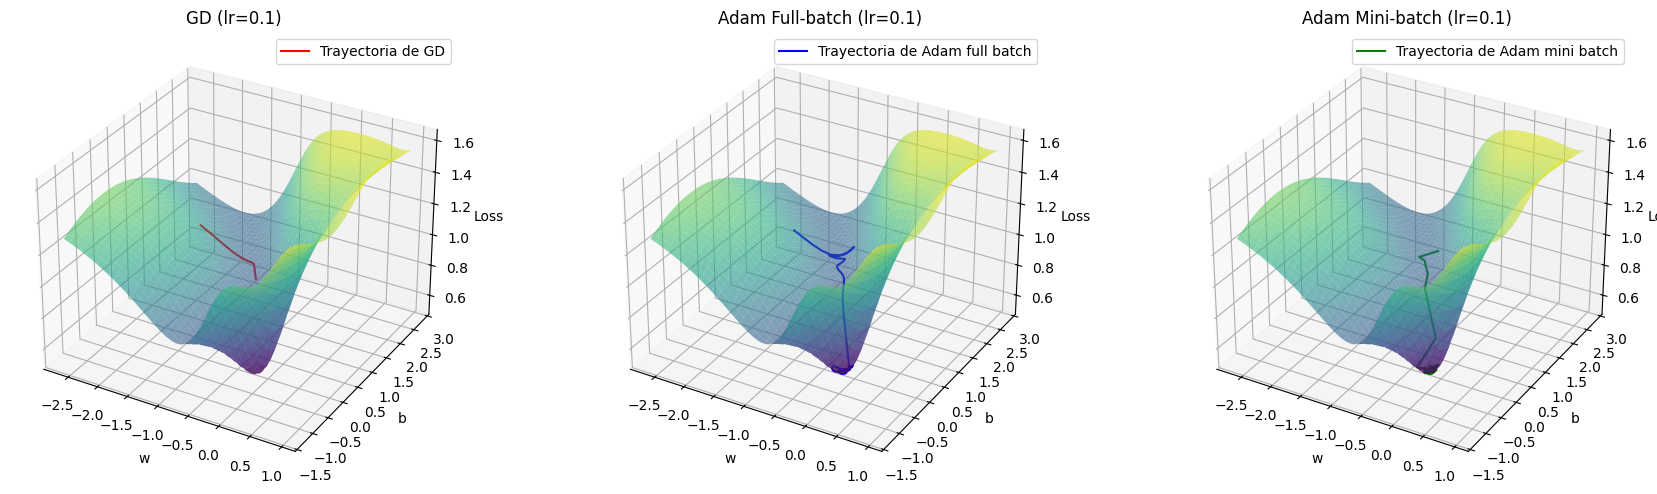

In [ ]:
chosen_lr = 0.1
traj_gd = results[chosen_lr]['gd']
traj_adam_full = results[chosen_lr]['adam_full']
traj_adam_mini = results[chosen_lr]['adam_mini']

w_vals = np.linspace(min(min(traj_gd['w']), min(traj_adam_full['w']), min(traj_adam_mini['w'])) - 1,
                     max(max(traj_gd['w']), max(traj_adam_full['w']), max(traj_adam_mini['w'])) + 1, 80)
b_vals = np.linspace(min(min(traj_gd['b']), min(traj_adam_full['b']), min(traj_adam_mini['b'])) - 1,
                     max(max(traj_gd['b']), max(traj_adam_full['b']), max(traj_adam_mini['b'])) + 1, 80)
W, B = np.meshgrid(w_vals, b_vals)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        yhat, _ = forward_pass(W[i,j], B[i,j], x)
        Z[i,j] = mse_loss(yhat, y)

fig = plt.figure(figsize=(18,5))

# GD
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(W, B, Z, cmap="viridis", alpha=0.6)
ax1.plot(traj_gd['w'], traj_gd['b'], traj_gd['loss'], color="red", label="Trayectoria de GD")
ax1.set_title("GD (lr=0.1)")
ax1.set_xlabel("w")
ax1.set_ylabel("b")
ax1.set_zlabel("Loss")
ax1.legend()

# Adam Full-batch
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(W, B, Z, cmap="viridis", alpha=0.6)
ax2.plot(traj_adam_full['w'], traj_adam_full['b'], traj_adam_full['loss'], color="blue", label="Trayectoria de Adam full batch")
ax2.set_title("Adam Full-batch (lr=0.1)")
ax2.set_xlabel("w")
ax2.set_ylabel("b")
ax2.set_zlabel("Loss")
ax2.legend()

# Adam Mini-batch
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(W, B, Z, cmap="viridis", alpha=0.6)
ax3.plot(traj_adam_mini['w'], traj_adam_mini['b'], traj_adam_mini['loss'], color="green", label="Trayectoria de Adam mini batch")
ax3.set_title("Adam Mini-batch (lr=0.1)")
ax3.set_xlabel("w")
ax3.set_ylabel("b")
ax3.set_zlabel("Loss")
ax3.legend()

plt.tight_layout()
plt.show()


- Gradient Descent (GD): sigue un recorrido más directo hacia la región de mínimo. Su trayectoria no presenta oscilaciones, pero converge de manera más lenta y se detiene antes de alcanzar la zona de menor costo.

- Adam Full-batch: presenta una trayectoria con oscilaciones iniciales. Sin embargo, logra acercarse al mínimo más que GD, mostrando una convergencia más estable a medida que avanzan las épocas.

- Adam Mini-batch: es el que muestra la trayectoria más efectiva. Aunque presenta oscilaciones, logra llegar más rápidamente y con mayor precisión a la región del mínimo global, alcanzando la mejor convergencia de los tres.

## **PREGUNTA 2**

2 a)

Bibliotecas necesarias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


In [ ]:
df = pd.read_csv("drive/MyDrive/dataset_compras.csv")
df.head()

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB


In [ ]:
filas,columnas = df.shape
print(f"El DataFrame tiene {filas} observaciones y {columnas} variables.")

El DataFrame tiene 182721 observaciones y 11 variables.


### **Análisis de duplicados**

In [ ]:
print("Cantidad de datos duplicados:", df.duplicated().sum())

Cantidad de datos duplicados: 2249


In [ ]:
df = df.drop_duplicates()
print("Duplicados después:", df.duplicated().sum())
df.shape

Duplicados después: 0


(180472, 11)

### **Conversión de tipos**

In [ ]:
df = df.copy()

cat_cols = [
    "Age", "Gender", "City_Category",
    "Stay_In_Current_City_Years", "Product_Category",
    "Product_Subcategory_1", "Product_Subcategory_2"
]

for c in cat_cols:
    df[c] = df[c].astype("category")


### **Valores únicos**

In [ ]:
cat_cols = ['Age', 'Gender', 'City_Category',
                  'Stay_In_Current_City_Years', 'Product_Category',
                  'Product_Subcategory_1', 'Product_Subcategory_2']

for col in cat_cols:
    print(f"Valores únicos en {col}:")
    print(df[col].unique())
    print()

Valores únicos en Age:
['46-50', '36-45', '18-25', '51-55', '55+', '26-35', '0-17']
Categories (7, object): ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

Valores únicos en Gender:
['F', 'M']
Categories (2, object): ['F', 'M']

Valores únicos en City_Category:
['B', 'A', 'C']
Categories (3, object): ['A', 'B', 'C']

Valores únicos en Stay_In_Current_City_Years:
['1', '3', '5+', '2', '4']
Categories (5, object): ['1', '2', '3', '4', '5+']

Valores únicos en Product_Category:
[10, 11, 4, 16, 3, ..., 20, 15, 8, 14, 7]
Length: 20
Categories (20, int64): [1, 2, 3, 4, ..., 17, 18, 19, 20]

Valores únicos en Product_Subcategory_1:
[45.0, 27.0, 28.0, 9.0, NaN, ..., 26.0, 5.0, 33.0, 8.0, 15.0]
Length: 34
Categories (33, float64): [3.0, 4.0, 5.0, 6.0, ..., 40.0, 42.0, 44.0, 45.0]

Valores únicos en Product_Subcategory_2:
[NaN, 8.0, 16.0, 5.0, 11.0, ..., 20.0, 12.0, 6.0, 15.0, 7.0]
Length: 17
Categories (16, float64): [5.0, 6.0, 7.0, 8.0, ..., 17.0, 18.0, 19.0, 20.0]



Podemos observar que Age, Gender, City_Category, Stay_In_Current_City_Years son de baja cardinalidad.

Product_Category, Product_Subcategory_1, Product_Subcategory_2 son de media/alta cardinalidad.

Esta información va a servir al momento de codificar estas variables categoricas



### **Análisis de nulos**

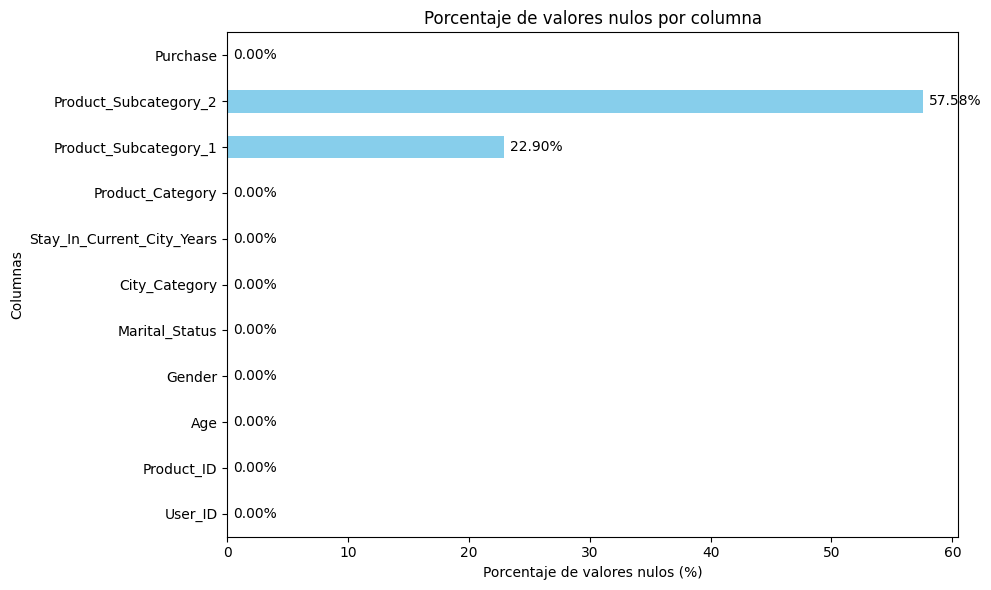

In [ ]:
porcentaje_nulos = df.isna().mean().round(4) * 100

plt.figure(figsize=(10, 6))
porcentaje_nulos.plot(kind='barh', color='skyblue')

plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Porcentaje de valores nulos (%)')
plt.ylabel('Columnas')

for index, value in enumerate(porcentaje_nulos):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center')

plt.tight_layout()
plt.show()

### **Matriz de valores faltantes**

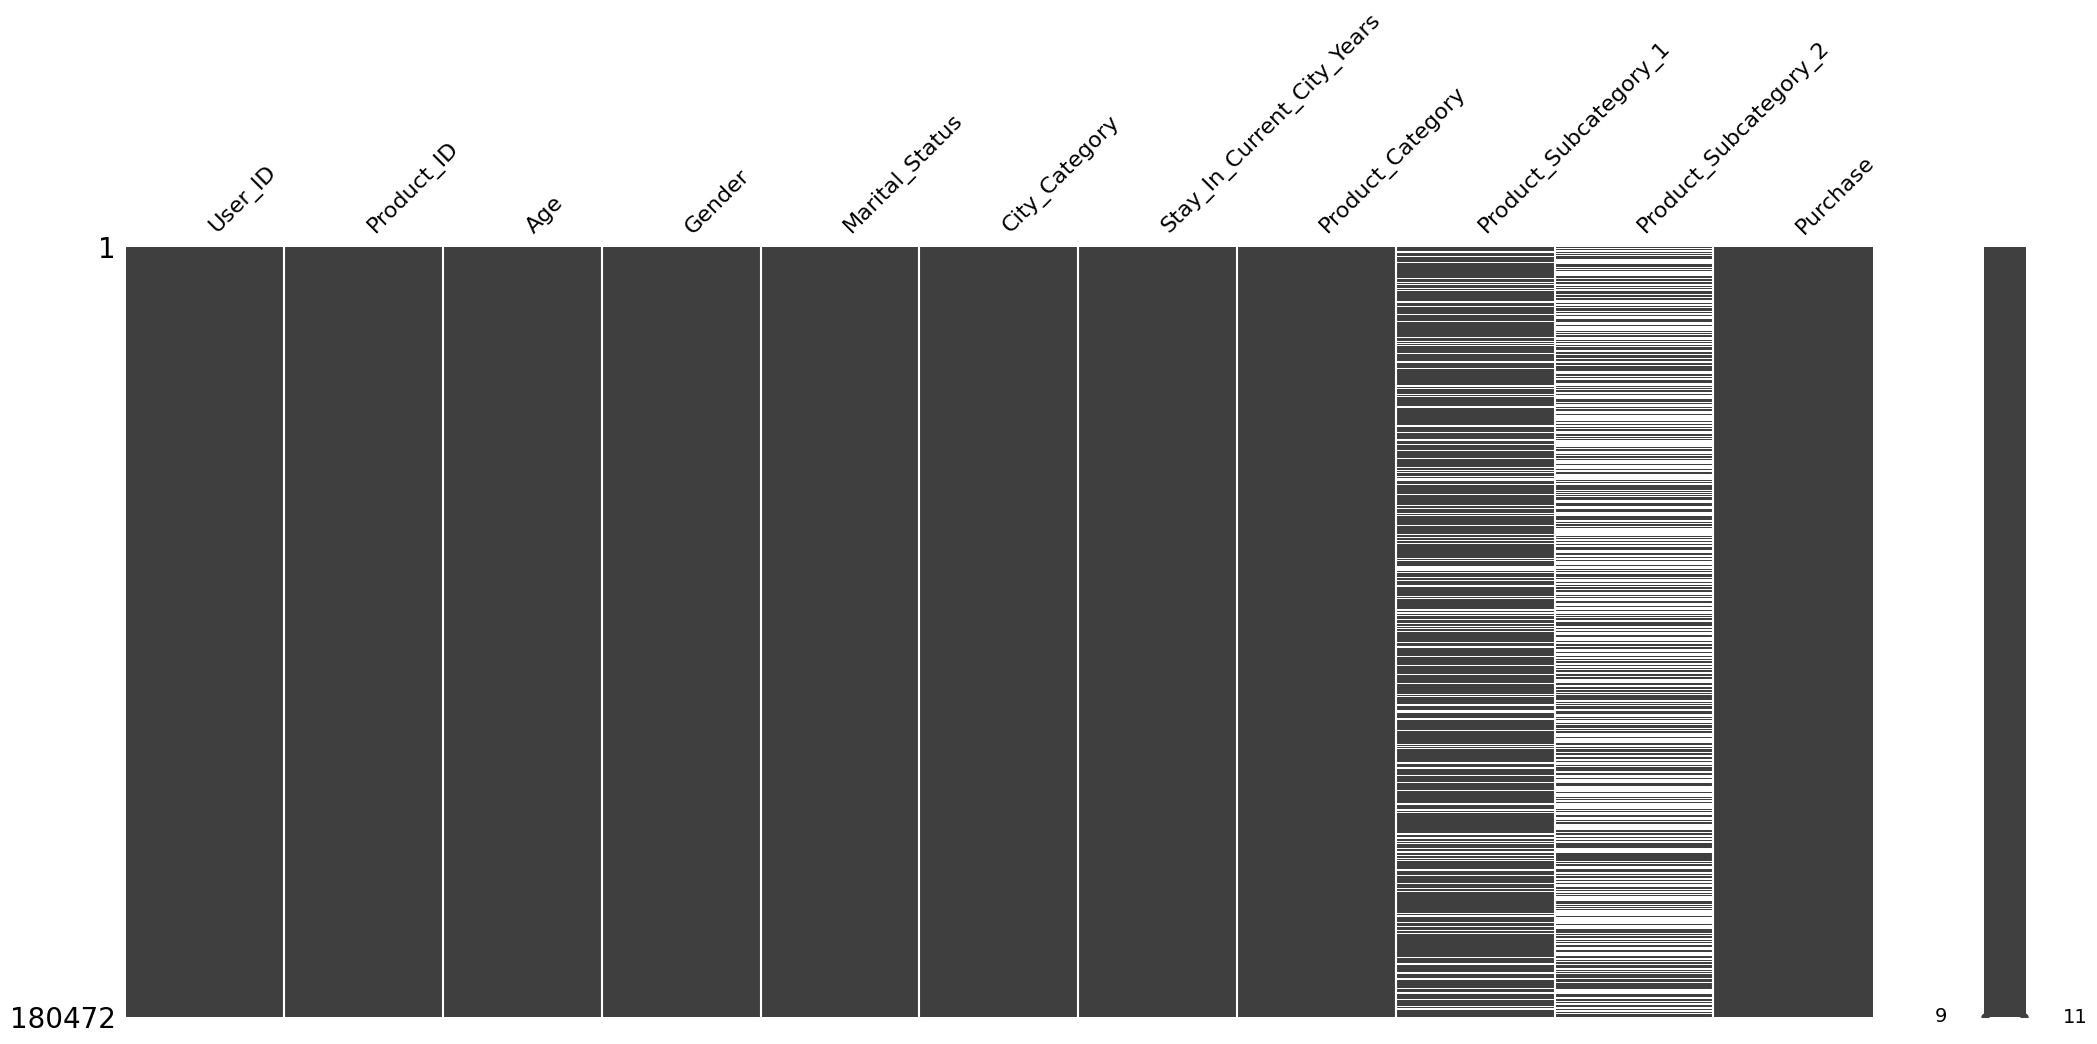

In [ ]:
msno.matrix(df)
plt.show()

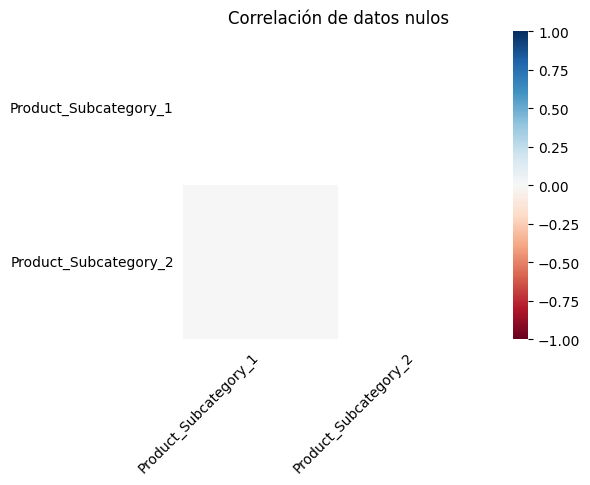

In [ ]:
msno.heatmap(df, fontsize=10, figsize=(5,4))
plt.title("Correlación de datos nulos", fontsize=12)
plt.show()

Luego de observar la matriz y el gráfico de correlación, no se observa relación de los faltantes entre product_subcategory_1 y product_subcategory_2.

En cuanto a product_subcategory_2 se observa que el porcentaje de faltantes es alto.

### **Análisis de outliers**

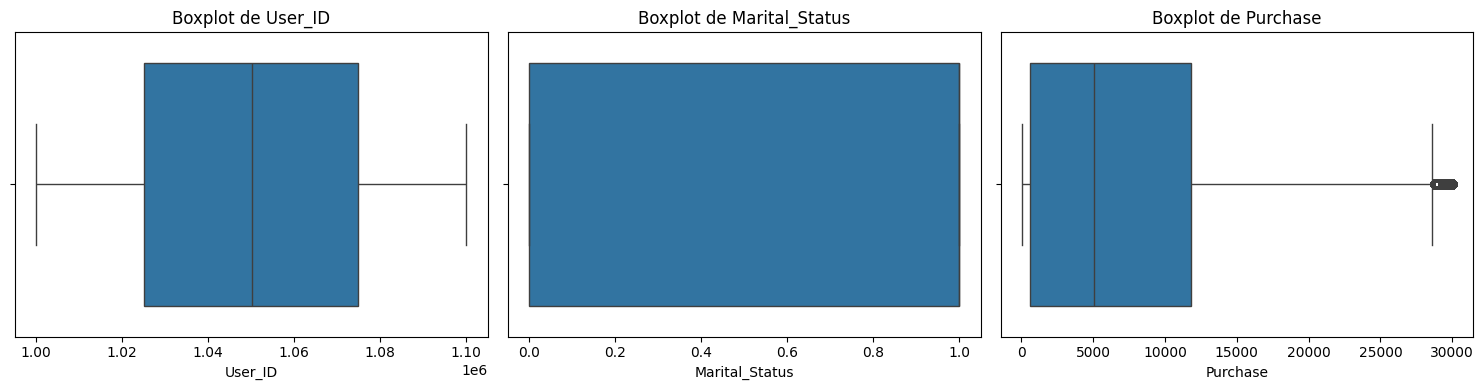

In [ ]:
columnas_numericas = df.select_dtypes(include='number').columns.to_list()

# Parámetros de layout
n_cols = 3  # Número de gráficos por fila
n_plots = len(columnas_numericas)
n_rows = math.ceil(n_plots / n_cols)

# Crea figura y ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

# Dibuja cada boxplot
for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")

# Oculta los ejes vacíos
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Los valores extremos de Purchase estarán representados en la categoría Premium del target.

### **Distribuciones**

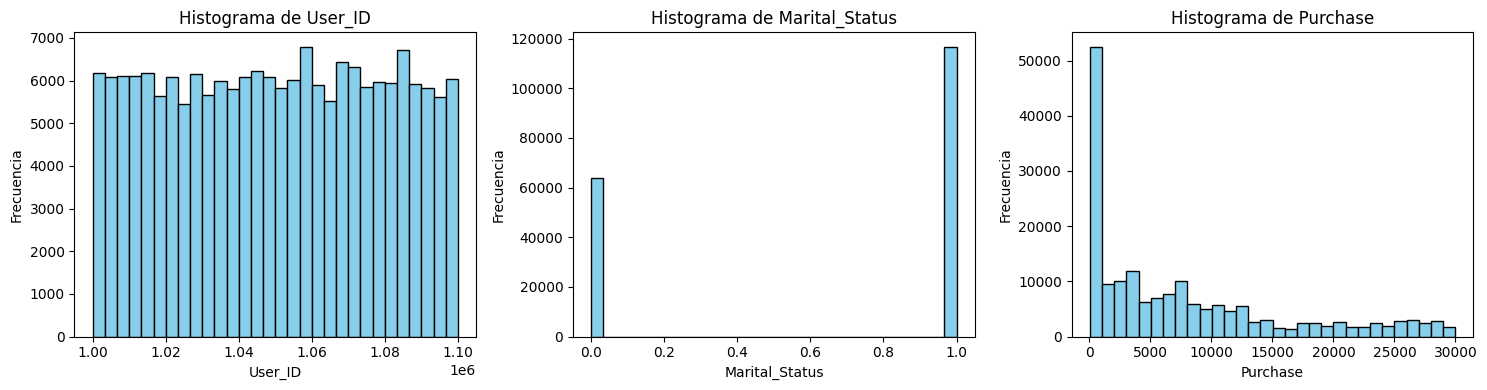

In [ ]:
# Lista de columnas numéricas
columnas_numericas = df.select_dtypes(include='number').columns.to_list()

# Parámetros para layout (3 gráficos por fila)
n_cols = 3
n_plots = len(columnas_numericas)
n_rows = (n_plots + n_cols - 1) // n_cols  # División redondeada hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Aplanar axes para iterar fácilmente, si solo hay 1 fila puede no ser array 2D
axes = axes.flatten() if n_plots > 1 else [axes]

# Graficar histogramas
for i, col in enumerate(columnas_numericas):
    axes[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f"Histograma de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Quitar ejes vacíos si los hay
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Se observa en purchase que existe un claro desbalance. Esto se va a tratar más adelante, al momento de aplicar el modelo, mediante el uso de una función de pérdida ponderada para darle más peso a las clases minoritarias.

En cuanto al estado civil, la mayoría de los usuarios son casados (suponiendo que 0 indica soltero y 1 indica casado), lo que podría reflejar una tendencia en los datos.

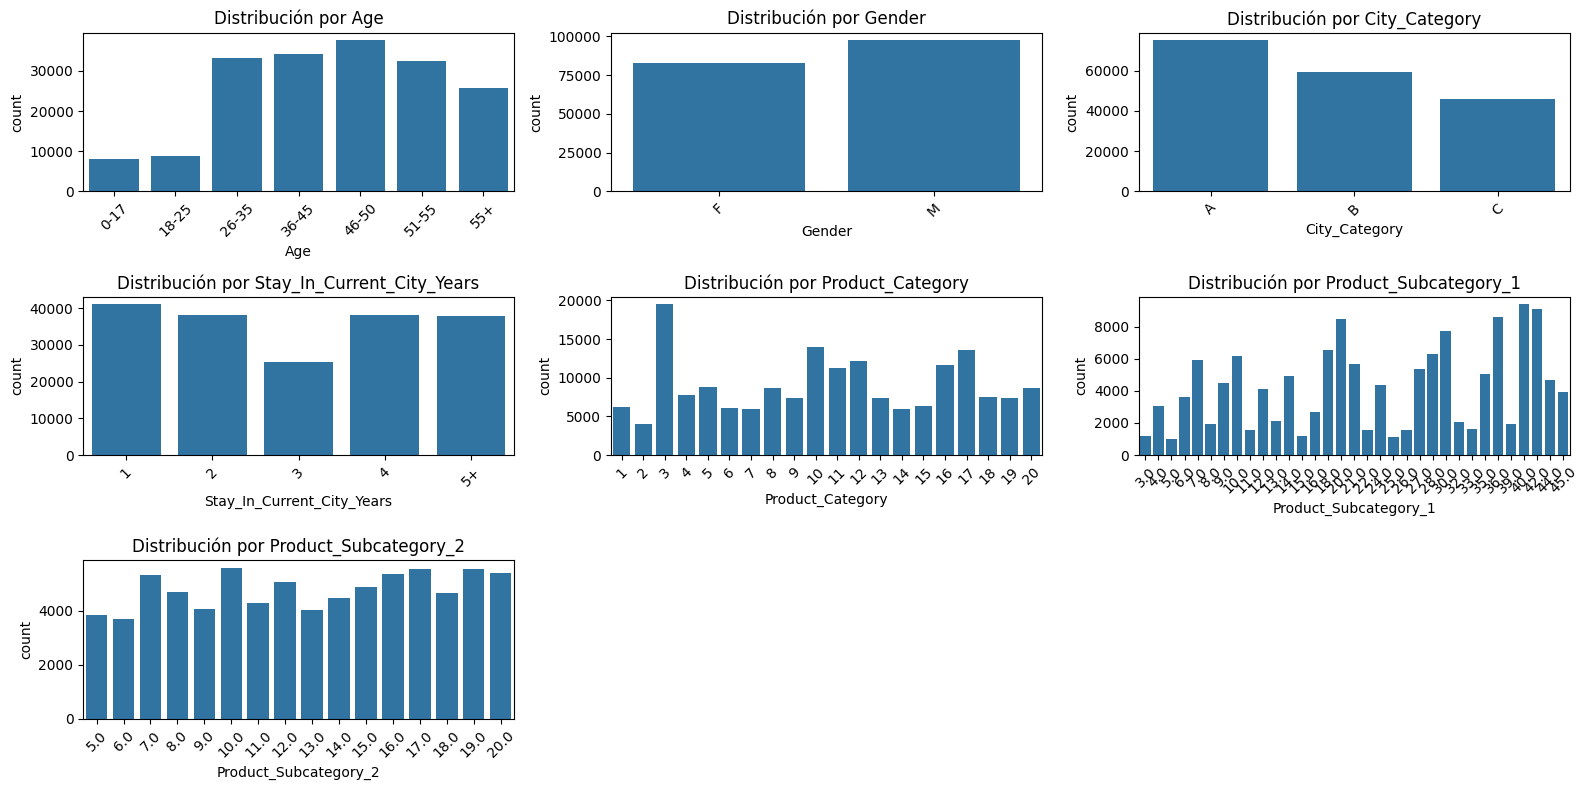

In [ ]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()


plot_cols = [c for c in cat_cols if c != 'Product_ID']

titles = [f"Distribución por {c}" for c in plot_cols]

fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].tick_params(axis='x', rotation=45)


for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


- Distribución por edad: la distribución de edades muestra un sesgo hacia grupos de mayor edad, como "46-50" y "36-45", mientras que los grupos más jóvenes tienen menos registros. Esto podría indicar que el modelo recibirá más datos de usuarios de mediana edad y más viejos.

- Distribución por género: la distribución es bastante equilibrada entre los géneros masculino y femenino.

- Distribución por categoría de ciudad: Hay una distribución sesgada hacia la categoría "A", lo que sugiere que la mayoría de los datos provienen de esta categoría.

- Distribución por años de permanencia en la ciudad actual: la distribución es relativamente equilibrada entre las diferentes categorías, aunque la mayor parte de los registros corresponden a aquellos que han vivido entre 1 y 2 años en la ciudad.

- Distribución por categoría de producto: la distribución de las categorías de productos muestra un comportamiento bastante disperso, con algunas categorías claramente más populares que otras.

- Distribución por subcategoría de producto 1: existe una gran variedad en las subcategorías de productos, lo que indica una posible alta cardinalidad.

- Distribución por Subcategoría de Producto 2: similar al anterior, la distribución en estas subcategorías también muestra una alta variabilidad.

Matriz de correlación

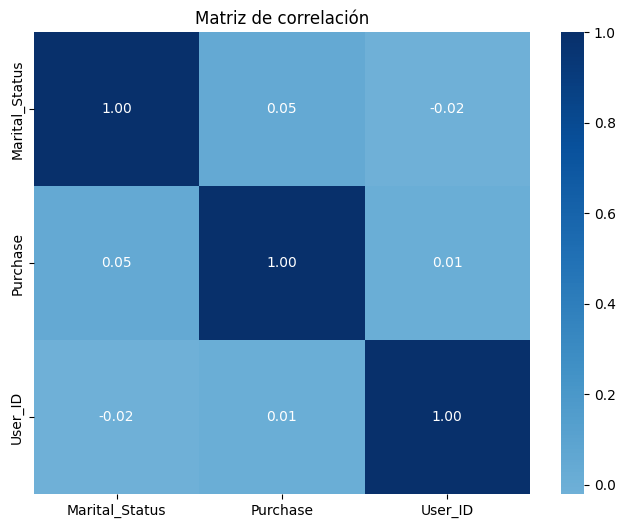

,Purchase
Purchase,1.000000
Marital_Status,0.046573
User_ID,0.005876


In [ ]:
num_cols = df.select_dtypes(include=['number']).columns.drop('Purchase')
corr = df[num_cols.union(['Purchase'])].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.color_palette("Blues", as_cmap=True), center=0)
plt.title('Matriz de correlación')
plt.show()

corr_with_target = corr['Purchase'].sort_values(ascending=False)
corr_with_target

Se observa que existe una correlación débil entre el target y el estado civil de la persona, por lo que es probable que esta variable no influya de manera significativa en los resultados al aplicar los modelos.

### **Creación target según enunciado**

In [ ]:
bins = [-np.inf, 3000, 8000, 18000, np.inf]
labels = ['Casual', 'Gama media', 'Gama alta', 'Premium']
df['Segment'] = pd.cut(df['Purchase'], bins=bins, labels=labels)
df = df.drop(columns=['Purchase'])

### **Split del dataset**

In [ ]:
X = df.drop(columns=['Segment'])
y = df['Segment'].astype('category').cat.codes
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### **Imputación de faltantes**

In [ ]:
col = 'Product_Subcategory_1'

X_train[col] = X_train[col].cat.add_categories(['Sin_subcategoria'])
X_train[col] = X_train[col].fillna('Sin_subcategoria')
X_val[col] = X_val[col].astype('category')
X_val[col] = X_val[col].cat.set_categories(X_train[col].cat.categories)
X_val[col] = X_val[col].fillna('Sin_subcategoria')

La columna Product_Subcategory_1 tiene un 22,9% de valores faltantes. Dado que es una variable categórica nominal, se decidió imputar los nulos creando una categoría especial "Sin_subcategoria". Esta estrategia permite conservar todas las filas y que el modelo aprenda si la ausencia de subcategoría tiene relación con el segmento de gasto. La categoría fue definida usando únicamente los datos de entrenamiento para evitar data leakage y luego aplicada al conjunto de validación.

En cuanto a la variable subcategory_2, el porcentaje de valores faltantes es muy alto (57,58%). Por este motivo, se decidió eliminar la columna y evaluar el desempeño de los modelos sin esta variable, verificando si aún se puede obtener un buen resultado.

### **Codificación**

Para el caso de Age y Stay_In_Current_City_Years, dado que las variables tienen un orden natural, se las codificará aplicando Ordinal Encoder.

In [ ]:
ordinal_cols = ['Age', 'Stay_In_Current_City_Years']

# Define orden de cada columna
age_categories = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
stay_categories = ['1','2','3','4','5+']

# Inicializa el encoder con las categorías ordenadas
ordinal_encoder = OrdinalEncoder(categories=[age_categories, stay_categories])

# Ajusta solo con X_train
X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])

# Transforma X_val con el mismo encoder
X_val[ordinal_cols] = ordinal_encoder.transform(X_val[ordinal_cols])


Para el caso de Gender, City_Category, al ser de baja cardinalidad se usará one hot encording para codificarlas.


In [ ]:
nominal_low_cols = ['Gender', 'City_Category']

onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')

# Ajusta y transforma
X_train_nominal = onehot_encoder.fit_transform(X_train[nominal_low_cols])
X_val_nominal   = onehot_encoder.transform(X_val[nominal_low_cols])

# Crea DataFrames con nombres correctos
X_train_nominal_df = pd.DataFrame(
    X_train_nominal,
    columns=onehot_encoder.get_feature_names_out(nominal_low_cols),
    index=X_train.index
)
X_val_nominal_df = pd.DataFrame(
    X_val_nominal,
    columns=onehot_encoder.get_feature_names_out(nominal_low_cols),
    index=X_val.index
)

# Elimina columnas originales y concatenar las nuevas
X_train = X_train.drop(columns=nominal_low_cols).join(X_train_nominal_df)
X_val = X_val.drop(columns=nominal_low_cols).join(X_val_nominal_df)



Product_Category y Product_Subcategory_1 tiene 20 y 33 valores únicos rspectivamente por lo que considero que sin de cardinalidad media. Por lo tanto se las codificará usando one hot encoding.

In [ ]:
product_cols = ['Product_Category', 'Product_Subcategory_1']

for col in product_cols:
    X_train[col] = X_train[col].astype(str)
    X_val[col]   = X_val[col].astype(str)


# One-hot encoder
product_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Ajustar y transformar X_train
X_train_product = product_encoder.fit_transform(X_train[product_cols])
X_val_product = product_encoder.transform(X_val[product_cols])

# Crear DataFrames con nombres correctos
X_train_product_df = pd.DataFrame(
    X_train_product,
    columns=product_encoder.get_feature_names_out(product_cols),
    index=X_train.index
)
X_val_product_df = pd.DataFrame(
    X_val_product,
    columns=product_encoder.get_feature_names_out(product_cols),
    index=X_val.index
)

# Eliminar columnas originales y concatenar
X_train = X_train.drop(columns=product_cols).join(X_train_product_df)
X_val = X_val.drop(columns=product_cols).join(X_val_product_df)

# Eliminación de columna Product_Subcategory_2
cols_to_drop = [c for c in X_train.columns if c.startswith('Product_Subcategory_2')]
X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)


In [ ]:
X_train.head()


,User_ID,Product_ID,Age,Marital_Status,Stay_In_Current_City_Years,Gender_M,City_Category_B,City_Category_C,Product_Category_1,Product_Category_10,...,Product_Subcategory_1_40.0,Product_Subcategory_1_42.0,Product_Subcategory_1_44.0,Product_Subcategory_1_45.0,Product_Subcategory_1_5.0,Product_Subcategory_1_6.0,Product_Subcategory_1_7.0,Product_Subcategory_1_8.0,Product_Subcategory_1_9.0,Product_Subcategory_1_Sin_subcategoria
32011,1081329,P00050604,4.0,1,4.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11776,1045990,P00012615,4.0,1,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56839,1009163,P00024866,4.0,1,2.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102414,1031659,P00028823,6.0,1,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
110331,1096967,P00060881,2.0,0,3.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train.info()



<class 'pandas.core.frame.DataFrame'>
Index: 144377 entries, 32011 to 33694
Data columns (total 62 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   User_ID                                 144377 non-null  int64  
 1   Product_ID                              144377 non-null  object 
 2   Age                                     144377 non-null  float64
 3   Marital_Status                          144377 non-null  int64  
 4   Stay_In_Current_City_Years              144377 non-null  float64
 5   Gender_M                                144377 non-null  float64
 6   City_Category_B                         144377 non-null  float64
 7   City_Category_C                         144377 non-null  float64
 8   Product_Category_1                      144377 non-null  float64
 9   Product_Category_10                     144377 non-null  float64
 10  Product_Category_11                     144377

## 2 b)

***Eliminación de columnas User_ID y Product_ID***

In [ ]:
X_train_dl = X_train.drop(columns=['User_ID', 'Product_ID'])
X_val_dl = X_val.drop(columns=['User_ID', 'Product_ID'])

In [ ]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Conversión a tensores float32
X_train_tensor = torch.tensor(X_train_dl.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_dl.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Creación datasets y dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)



In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], output_dim=4, dropout=0.3):
        super().__init__()
# La red neuronal definida en este modelo consta de varias capas lineales (nn.Linear) y una capa de regularización con dropout.
# La primera capa, self.fc1, es una capa lineal que toma la entrada con tamaño input_di y la transforma en una salida con tamaño hidden_dims[0],
# que corresponde a 128 neuronas. Luego, la segunda capa, self.fc2, toma esta salida de 128 neuronas y la reduce a una salida
# de tamaño hidden_dims[1] (64 neuronas). La última capa oculta, self.fc3, convierte la salida  de 64 neuronas en un vector de tamaño output_dim,
# que en este caso corresponde a 4 clases (correspondientes a las 4 categorías establecidas en el enunciado). Además, se utiliza self.dropout para aplicar
# dropout con una tasa del 30%, lo que significa que durante el entrenamiento, el 30% de las neuronas de la red serán aleatoriamente desactivadas
# en cada paso, ayudando a prevenir el sobreajuste y mejorando la generalización del modelo.
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [ ]:
input_dim = X_train_dl.shape[1]
model = MLP(input_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Calcula los pesos de las clases antes de iniciar el ciclo de entrenamiento. Esto se hace por el desbalance observado en el target purchase en la etapa
# de análisis del dataset
class_counts = np.bincount(y_train_tensor.cpu().numpy())
class_weights = 1. / class_counts  # Inversamente proporcional a la frecuencia
class_weights = class_weights / class_weights.sum()  # Normalizar para que sumen 1
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
input_size = X_train_dl.shape[1]
print(input_size)


60


El proceso de iteración en este modelo de deep learning se basa en el entrenamiento de una red neuronal de tres capas lineales, con activaciones ReLU, y una capa de regularización con dropout del 30% para prevenir el sobreajuste. El entrenamiento se realiza mediante un ciclo de 50 épocas , donde en cada una se calcula el loss en función de la CrossEntropyLoss, que es adecuada para tareas de clasificación multiclase que este problema requiere.

En cada época, se lleva a cabo el siguiente proceso:

- Entrenamiento: En la fase de entrenamiento, los datos de entrada se pasan a través del modelo, y las predicciones se comparan con las etiquetas verdaderas para calcular la pérdida. Luego, se realiza la retropropagación para actualizar los pesos del modelo usando el optimizador Adam. Durante esta fase, se calculan las métricas de accuracy y F1 score tanto para el conjunto de entrenamiento como para el conjunto de validación. Las métricas se almacenan para su posterior visualización y análisis.

- Validación: Después de cada ciclo de entrenamiento, se evalúa el modelo en el conjunto de validación. Durante esta fase, el modelo no actualiza sus pesos, sino que simplemente evalúa el desempeño sobre los datos no vistos. También se calculan las métricas de accuracy y F1 score para la validación.

In [ ]:
num_epochs = 50
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(num_epochs):
    # Entrenamiento
    model.train()
    epoch_loss = 0
    all_preds, all_labels = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Mueve los datos y target al dispositivo correspondiente (CPU o GPU).
        optimizer.zero_grad() # Limpia los gradientes acumulados de las iteraciones anteriores.
        outputs = model(X_batch) # Predicción sobre batch actual.
        loss = criterion(outputs, y_batch) # Calculo la pérdida.
        loss.backward() # Backpropagation
        optimizer.step() # Actualización de los parámetros del modelo.

        epoch_loss += loss.item() * X_batch.size(0)
        # Obtengo predicciones y almaceno para calcular las métricas
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    # Almaceno las métricas para la época de entrenamiento
    train_losses.append(epoch_loss / len(train_loader.dataset))
    train_accs.append(accuracy_score(all_labels, all_preds))
    train_f1s.append(f1_score(all_labels, all_preds, average='weighted'))

    # Validación
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_losses.append(val_loss / len(val_loader.dataset))
    val_accs.append(accuracy_score(val_labels, val_preds))
    val_f1s.append(f1_score(val_labels, val_preds, average='weighted'))


    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f} | Val F1: {val_f1s[-1]:.4f}")


Epoch 1/50 - Train Loss: 0.5270 | Val Loss: 0.4199 | Val Acc: 0.8126 | Val F1: 0.8120
Epoch 2/50 - Train Loss: 0.4256 | Val Loss: 0.4003 | Val Acc: 0.8134 | Val F1: 0.8123
Epoch 3/50 - Train Loss: 0.4107 | Val Loss: 0.3901 | Val Acc: 0.8115 | Val F1: 0.8122
Epoch 4/50 - Train Loss: 0.4034 | Val Loss: 0.3873 | Val Acc: 0.8105 | Val F1: 0.8101
Epoch 5/50 - Train Loss: 0.4003 | Val Loss: 0.3854 | Val Acc: 0.8132 | Val F1: 0.8122
Epoch 6/50 - Train Loss: 0.3975 | Val Loss: 0.3849 | Val Acc: 0.8150 | Val F1: 0.8143
Epoch 7/50 - Train Loss: 0.3962 | Val Loss: 0.3872 | Val Acc: 0.8159 | Val F1: 0.8142
Epoch 8/50 - Train Loss: 0.3949 | Val Loss: 0.3825 | Val Acc: 0.8153 | Val F1: 0.8160
Epoch 9/50 - Train Loss: 0.3940 | Val Loss: 0.3825 | Val Acc: 0.8153 | Val F1: 0.8158
Epoch 10/50 - Train Loss: 0.3926 | Val Loss: 0.3836 | Val Acc: 0.8177 | Val F1: 0.8171
Epoch 11/50 - Train Loss: 0.3924 | Val Loss: 0.3824 | Val Acc: 0.8149 | Val F1: 0.8155
Epoch 12/50 - Train Loss: 0.3922 | Val Loss: 0.3830 

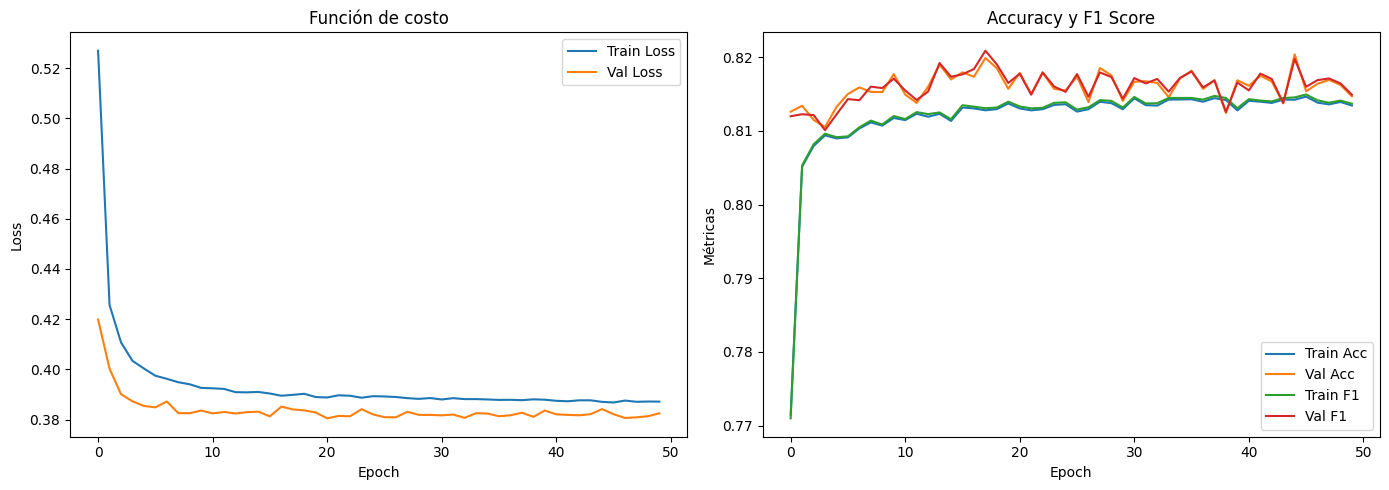

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Función de costo')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.plot(train_f1s, label='Train F1')
plt.plot(val_f1s, label='Val F1')
plt.xlabel('Epoch')
plt.ylabel('Métricas')
plt.title('Accuracy y F1 Score')
plt.legend()

plt.tight_layout()
plt.show()


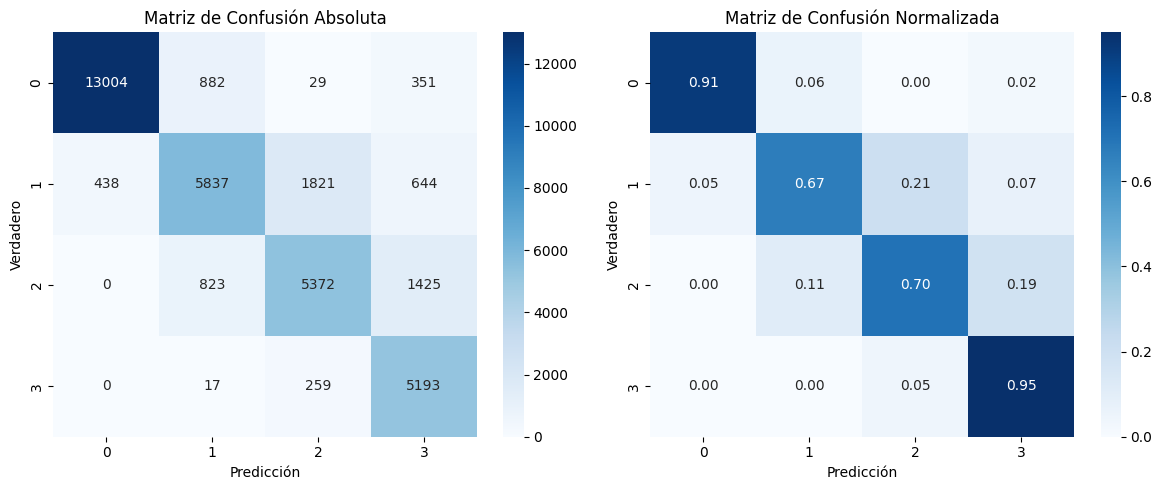

In [ ]:
cm = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión Absoluta')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')

plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matriz de Confusión Normalizada')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')

plt.tight_layout()
plt.show()


En este modelo, se abordó un problema de clasificación con un conjunto de datos que presenta un desbalance de clases significativo debido a la distribución de la variable Purchase. Dado que la mayoría de los usuarios realizan compras de bajo valor, mientras que las compras más altas son mucho menos frecuentes, el modelo tiende a predecir en su mayoría la clase correspondiente a compras pequeñas. Este desbalance puede hacer que el modelo sea sesgado y tenga un bajo rendimiento en la predicción de las clases menos frecuentes (como las compras "premium"). Es por ello que para mejorar el rendimiento del modelo en las clases desbalanceadas, se implementó la ponderación de la pérdida utilizando CrossEntropyLoss con un parámetro weight. Las pruebas se hicieron sin y con la ponderación, obteniendose los mejores resultados en el último caso.

Además de la ponderación de la pérdida, se experimentó con diferentes valores de la tasa de aprendizaje (lr) para encontrar la que optimizara mejor el modelo, obteniendose mejores resultados con el lr = 0.001.

Resultados Finales y Mejora en las Métricas

Tras aplicar la ponderación de la pérdida y usar una tasa de aprendizaje adecuada (0.001), los resultados mejoraron notablemente:

Clase 0 (Compra baja): El modelo predijo correctamente el 91% de los ejemplos de esta clase, lo que indica un excelente rendimiento para la clase mayoritaria.

Clase 1 (Compra media): El 68% de las predicciones fueron correctas, un avance respecto a la situación sin ponderación, aunque aún persisten algunos falsos negativos.

Clase 2 (Compra alta): El 70% de las predicciones fueron correctas, un avance respecto a la situación sin ponderación, aunque aún persisten algunos falsos negativos.

El 68% de las predicciones fueron correctas para esta clase, mostrando una mejora notable respecto a la configuración sin ponderación.

Clase 3 (Compra premium): La clase premium alcanzó el 94% de precisión, lo que indica que el modelo ahora predice correctamente las compras más grandes con una alta fiabilidad.

Las matrices de confusión (tanto absolutas como normalizadas) confirmaron la mejora, con una mayor tasa de aciertos en las clases minoritarias y una menor cantidad de falsos positivos y falsos negativos.


### **Conclusión**

En resumen, la combinación de ponderación de la pérdida y una tasa de aprendizaje adecuada permitió al modelo mejorar significativamente su capacidad para generalizar a las clases desbalanceadas, especialmente las de mayor valor. La ponderación de la pérdida ajustó el modelo para prestar más atención a las clases minoritarias, mientras que la tasa de aprendizaje más baja facilitó un entrenamiento más estable y efectivo.

## 2c)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144377 entries, 32011 to 33694
Data columns (total 62 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   User_ID                                 144377 non-null  int64  
 1   Product_ID                              144377 non-null  object 
 2   Age                                     144377 non-null  float64
 3   Marital_Status                          144377 non-null  int64  
 4   Stay_In_Current_City_Years              144377 non-null  float64
 5   Gender_M                                144377 non-null  float64
 6   City_Category_B                         144377 non-null  float64
 7   City_Category_C                         144377 non-null  float64
 8   Product_Category_1                      144377 non-null  float64
 9   Product_Category_10                     144377 non-null  float64
 10  Product_Category_11                     144377

Para entrenar un modelo de deep learning con embeddings en PyTorch, es necesario que las variables categóricas de alto cardinalidad, como User_ID y Product_ID, estén representadas como enteros consecutivos que comiencen en 0. Cada entero corresponde a un vector de embedding único en la capa nn.Embedding. Esto permite que la red aprenda una representación densa y continua de cada usuario o producto, capturando similitudes y relaciones entre ellos.

Se utilizó LabelEncoder para realizar esta codificación, ya que asigna automáticamente a cada categoría un entero único y consecutivo.

In [ ]:
# Codificar User_ID y Product_ID en índices enteros
user_encoder = LabelEncoder()
product_encoder = LabelEncoder()

X_train['User_ID_enc'] = user_encoder.fit_transform(X_train['User_ID'])
X_val['User_ID_enc']   = user_encoder.transform(X_val['User_ID'])

X_train['Product_ID_enc'] = product_encoder.fit_transform(X_train['Product_ID'])
X_val['Product_ID_enc']   = product_encoder.transform(X_val['Product_ID'])

# Guardar dimensiones de vocabulario
n_users = len(user_encoder.classes_)
n_products = len(product_encoder.classes_)

X_train_dl = X_train.drop(columns=['User_ID', 'Product_ID'])
X_val_dl = X_val.drop(columns=['User_ID', 'Product_ID'])


### Definición de modelo con embeddings

In [ ]:
class MLPWithEmbeddings(nn.Module):
    def __init__(self, n_users, n_products, n_numeric, emb_dim_user=16, hidden_dims=[32, 16], output_dim=4, dropout=0.6):
        super().__init__()

        # Embeddings
        self.user_emb = nn.Embedding(n_users, emb_dim_user)


        # Capa total de entrada = embeddings + numéricas
        input_dim = emb_dim_user + n_numeric

        # MLP
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, user_ids, numeric_feats):
        user_vec = self.user_emb(user_ids)


        # Concatenar embeddings + numéricas
        x = torch.cat([user_vec, numeric_feats], dim=1)

        # MLP
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [ ]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# Features numéricas = todas menos IDs
numeric_features = [c for c in X_train_dl.columns if c not in ['User_ID_enc', 'Product_ID_enc']]

X_train_user = torch.tensor(X_train_dl['User_ID_enc'].values, dtype=torch.long)
X_val_user   = torch.tensor(X_val_dl['User_ID_enc'].values, dtype=torch.long)

X_train_prod = torch.tensor(X_train_dl['Product_ID_enc'].values, dtype=torch.long)
X_val_prod   = torch.tensor(X_val_dl['Product_ID_enc'].values, dtype=torch.long)

X_train_num  = torch.tensor(X_train_dl[numeric_features].values, dtype=torch.float32)
X_val_num    = torch.tensor(X_val_dl[numeric_features].values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.long)

# Dataset y DataLoader
train_dataset = TensorDataset(X_train_user, X_train_num, y_train_tensor)
val_dataset   = TensorDataset(X_val_user, X_val_num, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)


Para la elección de los tamaños de embedding de user y product se tomó como base los experimentos que se hacen en el libro *"Modern Deep Learning for Tabular Data"* (Gorishniy et al., 2021, Cap. 3 y Cap. 5), donde se utilizan tamaños entre 16 y 32 que permiten capturar relaciones entre categorías de alta cardinalidad. Se realizaron experimentos con distintos tamaños y el que mejor resultado dio es 16 para user y 8 para product. Con estos valores se logró representar la información y, al mismo tiempo, reducir el riesgo de overfitting.


Respecto a las capas ocultas, se probaron varias configuraciones y se observó que esta combinación ofrecía los mejores resultados en términos de accuracy y F1 score sobre el conjunto de validación.

Se utilizó un dropout relativamente alto como herramienta de regularización, dado que los embeddings y las capas densas con estas dimensiones tendían a generar overfitting. La elección de este valor se basó en pruebas empíricas: valores menores no eran suficientes para estabilizar la validación, mientras que con 0.6 se logró un modelo más robusto y generalizable.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("users: ", n_users)
print("products: ", n_products)
model = MLPWithEmbeddings(
    n_users=n_users,
    n_products=n_products,
    n_numeric=len(numeric_features),
    emb_dim_user=64,
    hidden_dims=[64, 16],
    output_dim=4,
    dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(num_epochs):
    # Entrenamiento
    model.train()
    epoch_loss = 0
    all_preds, all_labels = [], []

    for user, feats, labels in train_loader:
        user, feats, labels = user.to(device), feats.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(user, feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * labels.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_losses.append(epoch_loss / len(train_loader.dataset))
    train_accs.append(accuracy_score(all_labels, all_preds))
    train_f1s.append(f1_score(all_labels, all_preds, average='weighted'))

    # Validación
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for user, feats, labels in val_loader:
            user, feats, labels = user.to(device), feats.to(device), labels.to(device)
            outputs = model(user, feats)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader.dataset))
    val_accs.append(accuracy_score(val_labels, val_preds))
    val_f1s.append(f1_score(val_labels, val_preds, average='weighted'))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f} | Val F1: {val_f1s[-1]:.4f}")


users:  7432
products:  2455
Epoch 1/50 - Train Loss: 0.6067 | Val Loss: 0.4798 | Val Acc: 0.7821 | Val F1: 0.7789
Epoch 2/50 - Train Loss: 0.4833 | Val Loss: 0.4591 | Val Acc: 0.7886 | Val F1: 0.7843
Epoch 3/50 - Train Loss: 0.4556 | Val Loss: 0.4355 | Val Acc: 0.7992 | Val F1: 0.7984
Epoch 4/50 - Train Loss: 0.4335 | Val Loss: 0.4294 | Val Acc: 0.8037 | Val F1: 0.8024
Epoch 5/50 - Train Loss: 0.4179 | Val Loss: 0.4248 | Val Acc: 0.8059 | Val F1: 0.8055
Epoch 6/50 - Train Loss: 0.4055 | Val Loss: 0.4236 | Val Acc: 0.8038 | Val F1: 0.8023
Epoch 7/50 - Train Loss: 0.3939 | Val Loss: 0.4248 | Val Acc: 0.7977 | Val F1: 0.7986
Epoch 8/50 - Train Loss: 0.3823 | Val Loss: 0.4296 | Val Acc: 0.8000 | Val F1: 0.8011
Epoch 9/50 - Train Loss: 0.3723 | Val Loss: 0.4413 | Val Acc: 0.7989 | Val F1: 0.7985
Epoch 10/50 - Train Loss: 0.3609 | Val Loss: 0.4482 | Val Acc: 0.7983 | Val F1: 0.7986
Epoch 11/50 - Train Loss: 0.3498 | Val Loss: 0.4652 | Val Acc: 0.7988 | Val F1: 0.7971
Epoch 12/50 - Train Los

El proceso de iteración en este modelo de deep learning se basa en el entrenamiento de una red neuronal con dos capas de embeddings (una para usuarios y otra para productos) que se combinan con variables numéricas, seguida de un MLP de dos capas lineales con activaciones ReLU y regularización mediante dropout del 60% para prevenir el sobreajuste. El entrenamiento se realiza durante 50 épocas, utilizando CrossEntropyLoss, adecuada para la tarea de clasificación multiclase que requiere este problema.

En cada época, se lleva a cabo el siguiente proceso:

- Entrenamiento: Durante la fase de entrenamiento, los datos de entrada se pasan a través del modelo para generar predicciones, que se comparan con las etiquetas verdaderas para calcular la pérdida. Luego, se realiza la retropropagación para actualizar los pesos del modelo usando el optimizador Adam. Durante esta fase, se calculan las métricas de accuracy y F1 score sobre el conjunto de entrenamiento y se almacenan para su posterior análisis.

- Validación: Al finalizar cada época de entrenamiento, se evalúa el modelo sobre el conjunto de validación, sin actualizar los pesos. En esta fase se calculan las mismas métricas para monitorear el desempeño sobre datos no vistos, permitiendo identificar problemas de overfitting o underfitting y ajustar los hiperparámetros si fuera necesario.

In [ ]:
plt.figure(figsize=(14,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Función de costo')
plt.legend()

# Accuracy y F1
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.plot(train_f1s, label='Train F1')
plt.plot(val_f1s, label='Val F1')
plt.xlabel('Epoch')
plt.ylabel('Métricas')
plt.title('Accuracy y F1 Score')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
cm = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,5))

# Absoluta
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión Absoluta')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')

# Normalizada
plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matriz de Confusión Normalizada')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')

plt.tight_layout()
plt.show()
